In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import kurtosis, skew

np.random.seed(42)

In [7]:
df = pd.read_csv('sp500_90.csv', parse_dates=['date'], index_col='date')
returns = df['sp500'] * 100  # percentage returns

# Fit GJR-GARCH(1,1) — equivalent to T-GARCH in the example code
# h_t = omega + alpha * e_{t-1}^2 + gamma * e_{t-1}^2 * I(e_{t-1}<0) + beta * h_{t-1}
am = arch_model(returns, mean='Zero', vol='GARCH', p=1, o=1, q=1)
res = am.fit(disp='off')
print(res.summary())

                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:                  sp500   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -11555.4
Distribution:                  Normal   AIC:                           23118.9
Method:            Maximum Likelihood   BIC:                           23147.2
                                        No. Observations:                 8817
Date:                Fri, Feb 27 2026   Df Residuals:                     8817
Time:                        12:37:14   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0204  5.018e-03      4.069  4.714e-05 

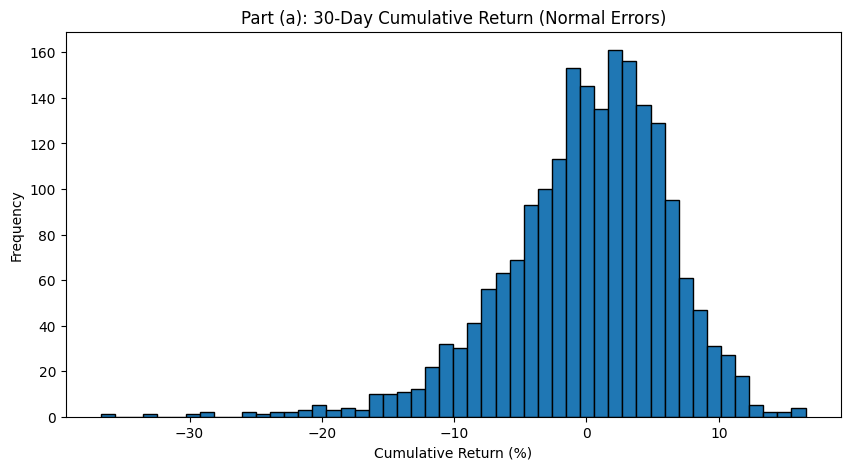

In [8]:
# Extract parameters
omega = res.params['omega']
alpha = res.params['alpha[1]']
gamma_gjr = res.params['gamma[1]']
beta = res.params['beta[1]']

# Compute h_{T+1} from last observed return and last conditional variance
h_T = res.conditional_volatility.iloc[-1]**2
r_T = res.resid.iloc[-1]
h_start = omega + alpha * r_T**2 + gamma_gjr * r_T**2 * (r_T < 0) + beta * h_T

# Standardized residuals for bootstrap (part b)
std_resid = (res.resid / res.conditional_volatility).dropna().values

nperiods = 30
nsim = 2000

# --- Part (a): Normal errors ---
eps_norm = np.random.normal(0, 1, (nsim, nperiods))
ret_cum_norm = np.zeros(nsim)
h = np.full(nsim, h_start)

for i in range(nperiods):
    r = eps_norm[:, i] * np.sqrt(h)
    ret_cum_norm += r
    h = omega + alpha * r**2 + gamma_gjr * r**2 * (r < 0) + beta * h

plt.figure(figsize=(10, 5))
plt.hist(ret_cum_norm, bins=50, edgecolor='black')
plt.title('Part (a): 30-Day Cumulative Return (Normal Errors)')
plt.xlabel('Cumulative Return (%)')
plt.ylabel('Frequency')
plt.show()

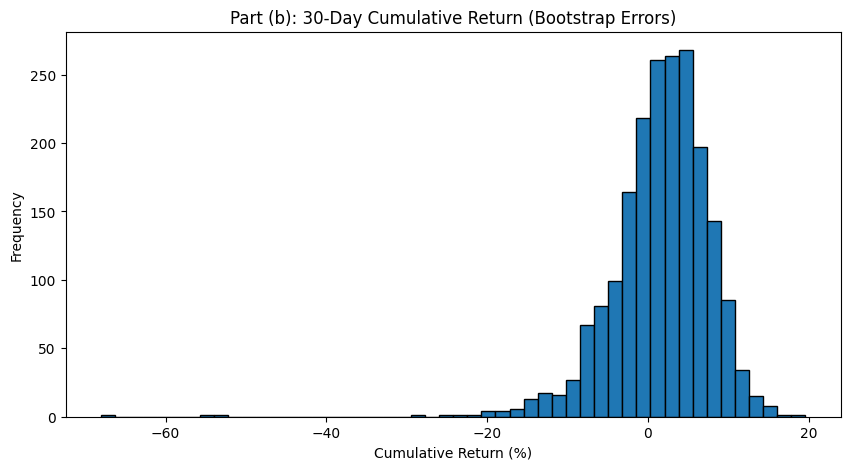

In [9]:
# --- Part (b): Bootstrap errors ---
idx = np.random.randint(0, len(std_resid), (nsim, nperiods))
eps_boot = std_resid[idx]
ret_cum_boot = np.zeros(nsim)
h = np.full(nsim, h_start)

for i in range(nperiods):
    r = eps_boot[:, i] * np.sqrt(h)
    ret_cum_boot += r
    h = omega + alpha * r**2 + gamma_gjr * r**2 * (r < 0) + beta * h

plt.figure(figsize=(10, 5))
plt.hist(ret_cum_boot, bins=50, edgecolor='black')
plt.title('Part (b): 30-Day Cumulative Return (Bootstrap Errors)')
plt.xlabel('Cumulative Return (%)')
plt.ylabel('Frequency')
plt.show()

In [11]:
# Part (c): Kurtosis and Skewness
print("Part (c): Kurtosis and Skewness of 30-day returns")
print(f"  Normal:    skewness = {skew(ret_cum_norm):.4f},  kurtosis = {kurtosis(ret_cum_norm, fisher=False):.4f}")
print(f"  Bootstrap: skewness = {skew(ret_cum_boot):.4f},  kurtosis = {kurtosis(ret_cum_boot, fisher=False):.4f}")

# Part (d): 1% VaR
var_norm = -np.percentile(ret_cum_norm, 1)
var_boot = -np.percentile(ret_cum_boot, 1)
print(f"\nPart (d): 1% VaR for 30-day returns")
print(f"  Normal:    {var_norm:.4f}%")
print(f"  Bootstrap: {var_boot:.4f}%")

# Part (e): P(return < -15%)
p_put_norm = np.mean(ret_cum_norm < -15)
p_put_boot = np.mean(ret_cum_boot < -15)
print(f"\nPart (e): P(30-day return < -15%)")
print(f"  Normal:    {p_put_norm:.4f}")
print(f"  Bootstrap: {p_put_boot:.4f}")

# Part (f): P(return > 15%)
p_call_norm = np.mean(ret_cum_norm > 15)
p_call_boot = np.mean(ret_cum_boot > 15)
print(f"\nPart (f): P(30-day return > 15%)")
print(f"  Normal:    {p_call_norm:.4f}")
print(f"  Bootstrap: {p_call_boot:.4f}")

# Part (g)
print("\nPart (g):")
print("The put option (right to sell at 15% below) should be more valuable.")
print("The GJR-GARCH leverage effect means negative shocks increase")
print("volatility more than positive shocks, creating negative skewness in")
print("returns. This makes large declines more probable than")
print("large rises of equal magnitude, so the put has a higher expected payoff.")

Part (c): Kurtosis and Skewness of 30-day returns
  Normal:    skewness = -0.9124,  kurtosis = 5.1622
  Bootstrap: skewness = -1.9801,  kurtosis = 17.7342

Part (d): 1% VaR for 30-day returns
  Normal:    19.5783%
  Bootstrap: 15.8706%

Part (e): P(30-day return < -15%)
  Normal:    0.0220
  Bootstrap: 0.0110

Part (f): P(30-day return > 15%)
  Normal:    0.0020
  Bootstrap: 0.0035

Part (g):
The put option (right to sell at 15% below) should be more valuable.
The GJR-GARCH leverage effect means negative shocks increase
volatility more than positive shocks, creating negative skewness in
returns. This makes large declines more probable than
large rises of equal magnitude, so the put has a higher expected payoff.
